In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ds=pd.read_csv('D:\\Bank\\artifacts\\data_ingestion\\unzipped\\customer_churn_dataset-testing-master.csv')

In [4]:
ds.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [5]:
ds=ds.drop(columns=["CustomerID"])

In [6]:
ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                64374 non-null  int64
 1   Gender             64374 non-null  str  
 2   Tenure             64374 non-null  int64
 3   Usage Frequency    64374 non-null  int64
 4   Support Calls      64374 non-null  int64
 5   Payment Delay      64374 non-null  int64
 6   Subscription Type  64374 non-null  str  
 7   Contract Length    64374 non-null  str  
 8   Total Spend        64374 non-null  int64
 9   Last Interaction   64374 non-null  int64
 10  Churn              64374 non-null  int64
dtypes: int64(8), str(3)
memory usage: 5.4 MB


In [7]:
ds.columns = ds.columns.str.replace(" ", "")

In [8]:
ds.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,64374.0,41.970982,13.924911,18.0,30.0,42.0,54.0,65.0
Tenure,64374.0,31.994827,17.098234,1.0,18.0,33.0,47.0,60.0
UsageFrequency,64374.0,15.080234,8.816470,1.0,7.0,15.0,23.0,30.0
SupportCalls,64374.0,5.400690,3.114005,0.0,3.0,6.0,8.0,10.0
PaymentDelay,64374.0,17.133952,8.852211,0.0,10.0,19.0,25.0,30.0
TotalSpend,64374.0,541.023379,260.874809,100.0,313.0,534.0,768.0,1000.0
LastInteraction,64374.0,15.498850,8.638436,1.0,8.0,15.0,23.0,30.0
Churn,64374.0,0.473685,0.499311,0.0,0.0,0.0,1.0,1.0


In [9]:
ds.columns.values

<StringArray>
[             'Age',           'Gender',           'Tenure',
   'UsageFrequency',     'SupportCalls',     'PaymentDelay',
 'SubscriptionType',   'ContractLength',       'TotalSpend',
  'LastInteraction',            'Churn']
Length: 11, dtype: str

In [10]:
ds.select_dtypes(include=['str']).columns


Index(['Gender', 'SubscriptionType', 'ContractLength'], dtype='str')

In [11]:
ds['ContractLength'].value_counts()

ContractLength
Monthly      22130
Annual       21410
Quarterly    20834
Name: count, dtype: int64

In [12]:
ds['SubscriptionType'].value_counts()

SubscriptionType
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64

In [13]:
ds.isnull().sum()

Age                 0
Gender              0
Tenure              0
UsageFrequency      0
SupportCalls        0
PaymentDelay        0
SubscriptionType    0
ContractLength      0
TotalSpend          0
LastInteraction     0
Churn               0
dtype: int64

In [14]:
ds.duplicated().sum()

np.int64(0)

In [15]:
ds['Churn'].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

In [16]:
ds.head()

,Age,Gender,Tenure,UsageFrequency,SupportCalls,PaymentDelay,SubscriptionType,ContractLength,TotalSpend,LastInteraction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [17]:
Q1 = ds.quantile(0.25, numeric_only = True)
Q3 = ds.quantile(0.75, numeric_only = True)
IQR = Q3 - Q1
print(IQR)

Age                 24.0
Tenure              29.0
UsageFrequency      16.0
SupportCalls         5.0
PaymentDelay        15.0
TotalSpend         455.0
LastInteraction     15.0
Churn                1.0
dtype: float64


In [18]:
min=Q1 - 1.5 * IQR
max=Q3 + 1.5 * IQR

In [20]:
numeric=ds.select_dtypes(include=['int64','float64'])
numeric

,Age,Tenure,UsageFrequency,SupportCalls,PaymentDelay,TotalSpend,LastInteraction,Churn
0,22,25,14,4,27,598,9,1
1,41,28,28,7,13,584,20,0
2,47,27,10,2,29,757,21,0
3,35,9,12,5,17,232,18,0
4,53,58,24,9,2,533,18,0
...,...,...,...,...,...,...,...,...
64369,45,33,12,6,21,947,14,1
64370,37,6,1,5,22,923,9,1
64371,25,39,14,8,30,327,20,1
64372,50,18,19,7,22,540,13,1


In [21]:
outlier_mask = numeric.lt(min[numeric.columns]) | numeric.gt(max[numeric.columns])

outlier_counts = outlier_mask.sum().sort_values(ascending=False)
print("Outlier count per column:")
display(outlier_counts)

outlier_rows = numeric[outlier_mask.any(axis=1)]
display(outlier_rows)

Outlier count per column:


Age                0
Tenure             0
UsageFrequency     0
SupportCalls       0
PaymentDelay       0
TotalSpend         0
LastInteraction    0
Churn              0
dtype: int64

,Age,Tenure,UsageFrequency,SupportCalls,PaymentDelay,TotalSpend,LastInteraction,Churn


,Age,Tenure,UsageFrequency,SupportCalls,PaymentDelay,TotalSpend,LastInteraction,Churn
Age,1.000000,-0.007763,-0.038331,0.005014,-0.016132,0.006490,-0.000148,0.063457
Tenure,-0.007763,1.000000,0.023485,0.060065,0.055963,0.009474,0.005770,0.195327
UsageFrequency,-0.038331,0.023485,1.000000,-0.014072,0.031132,0.001527,-0.009192,-0.115098
SupportCalls,0.005014,0.060065,-0.014072,1.000000,0.064298,0.021750,0.001666,0.304631
PaymentDelay,-0.016132,0.055963,0.031132,0.064298,1.000000,-0.031119,-0.008076,0.557386
TotalSpend,0.006490,0.009474,0.001527,0.021750,-0.031119,1.000000,-0.007692,-0.078867
LastInteraction,-0.000148,0.005770,-0.009192,0.001666,-0.008076,-0.007692,1.000000,-0.002818
Churn,0.063457,0.195327,-0.115098,0.304631,0.557386,-0.078867,-0.002818,1.000000


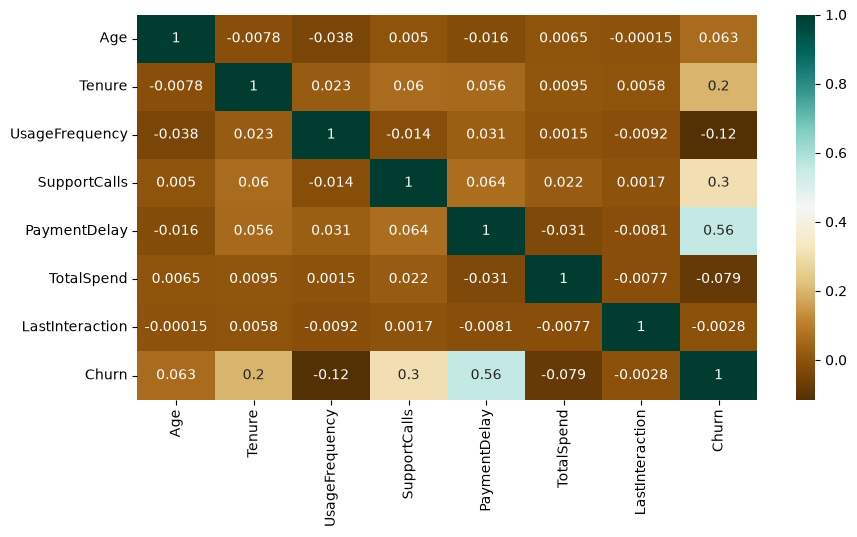

In [22]:
plt.figure(figsize=(10,5))
c = numeric.corr()
sns.heatmap(c,cmap="BrBG",annot=True)
c

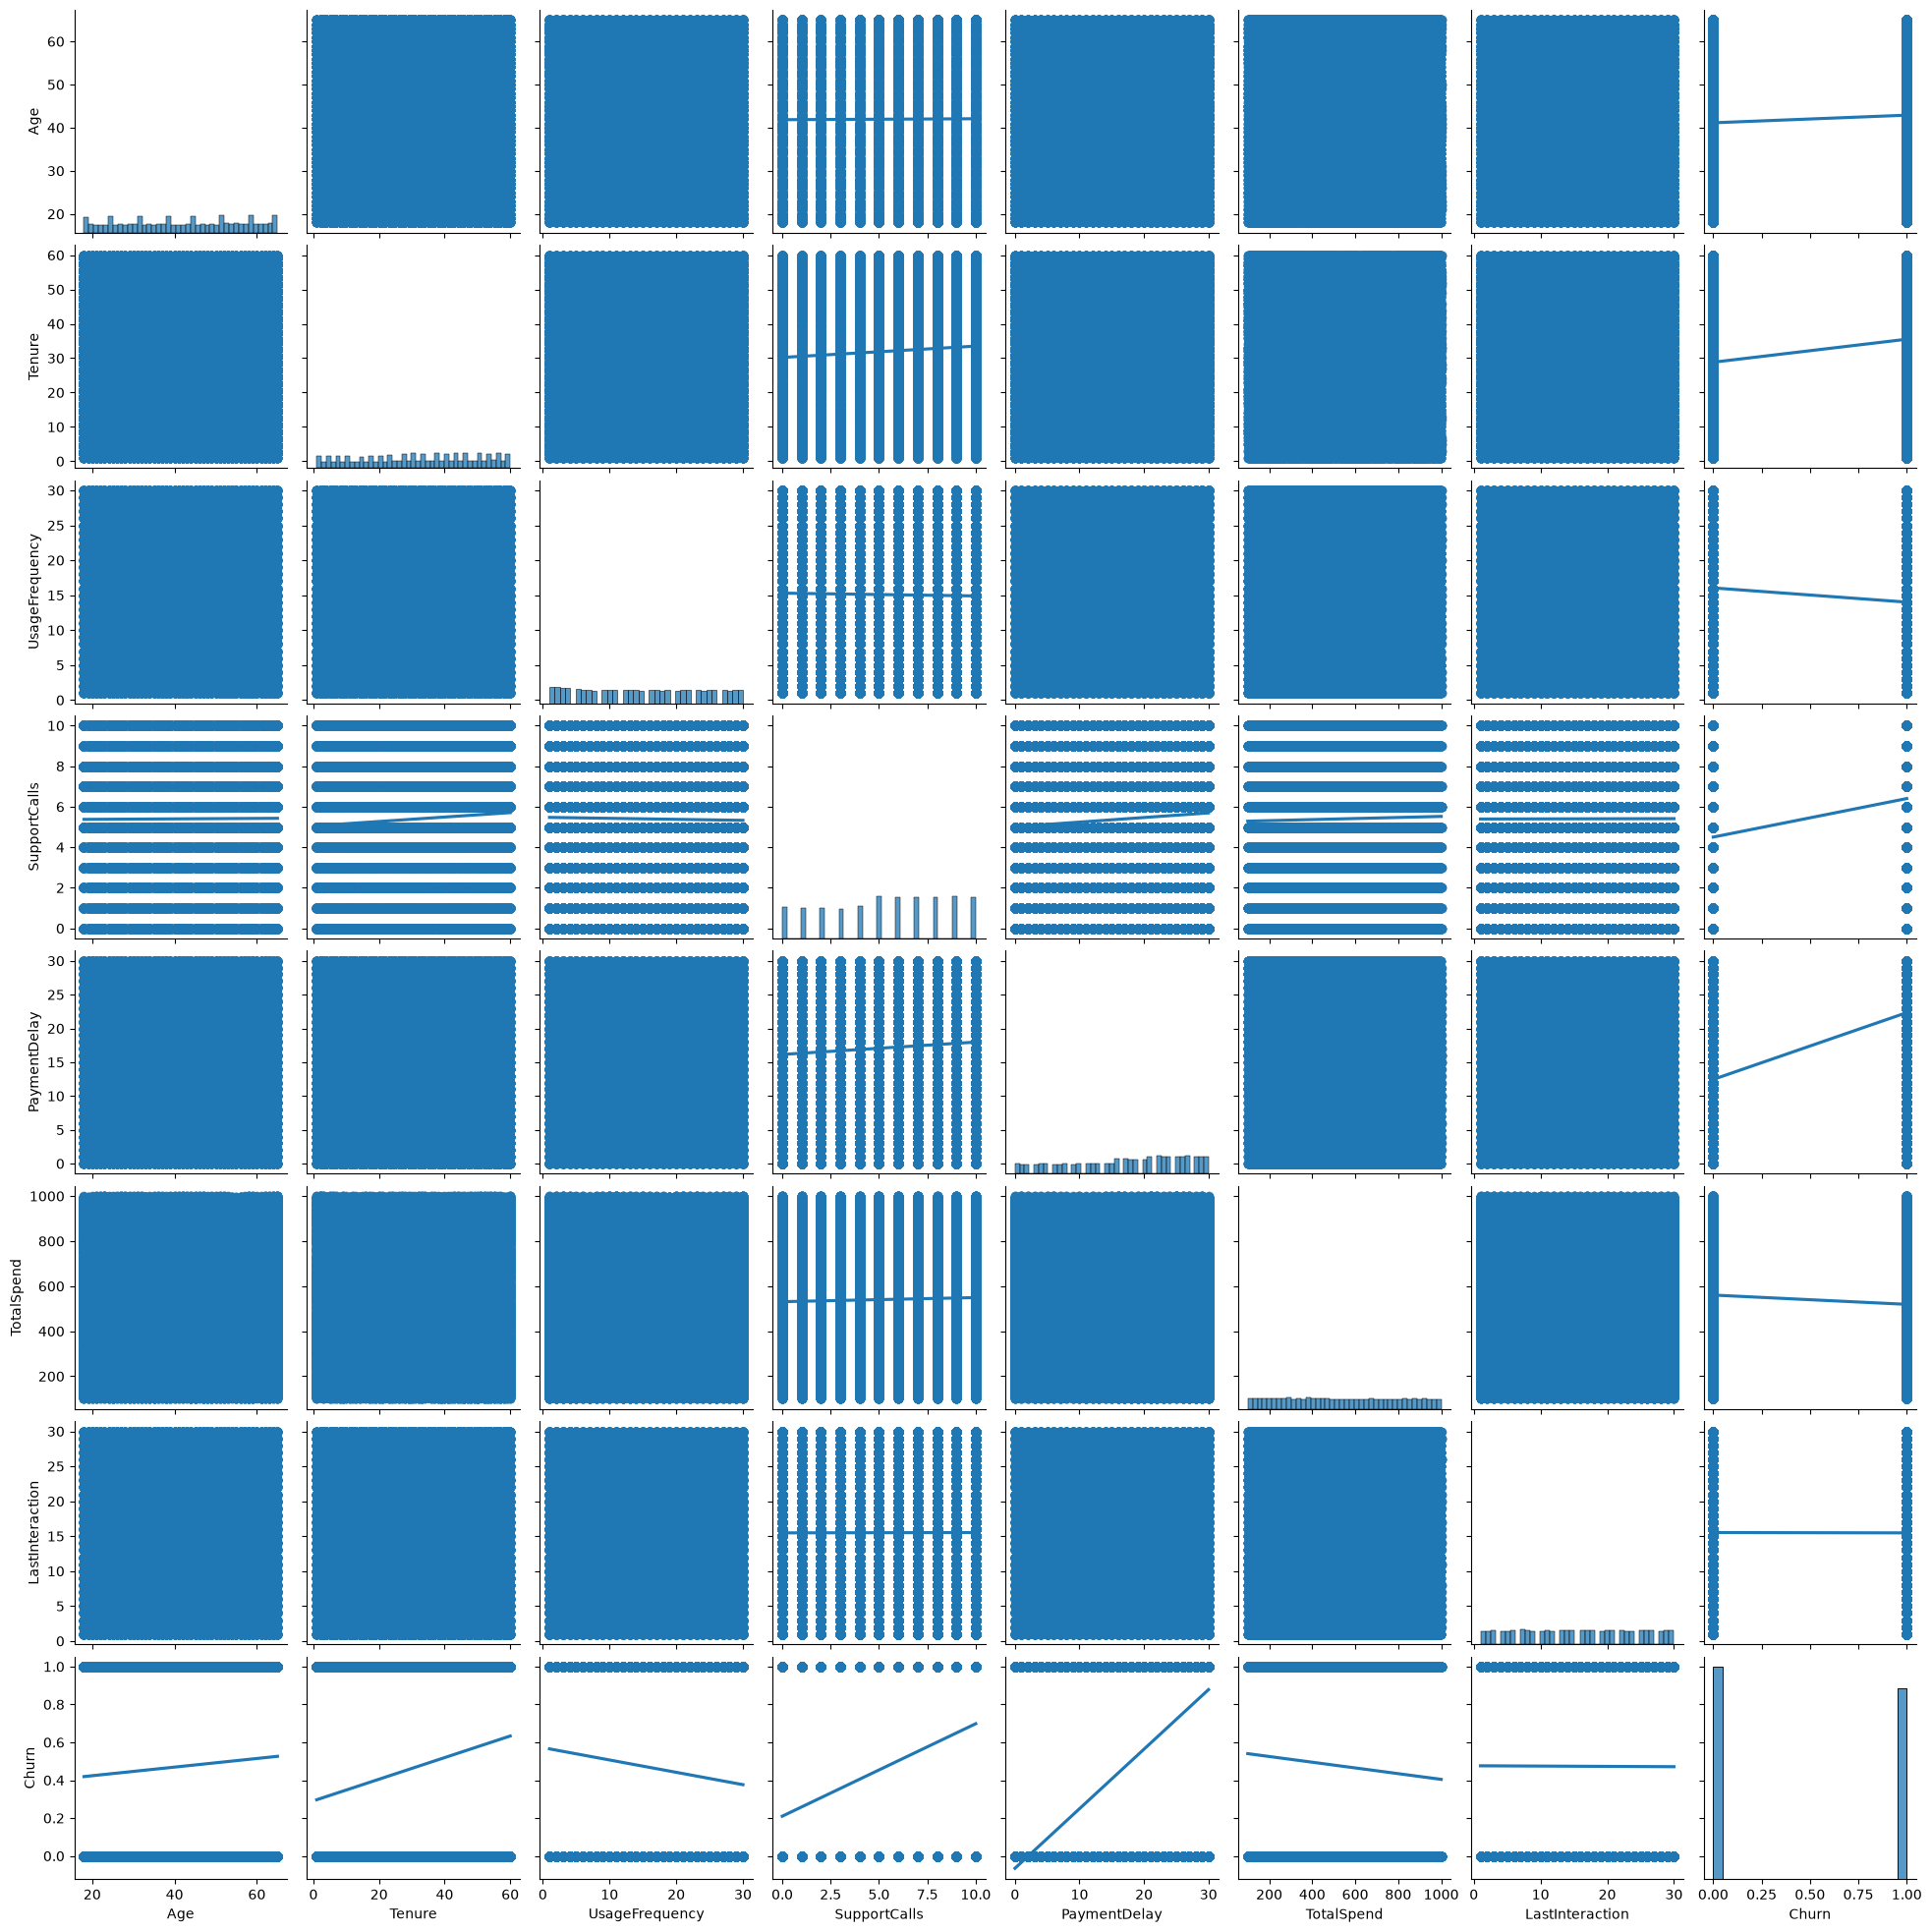

In [24]:
sns.pairplot(numeric, kind="reg")

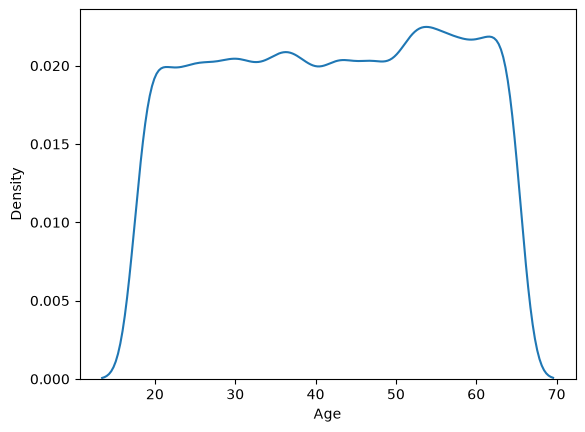

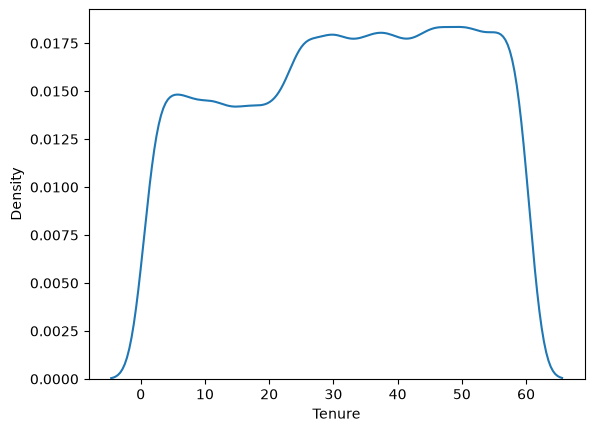

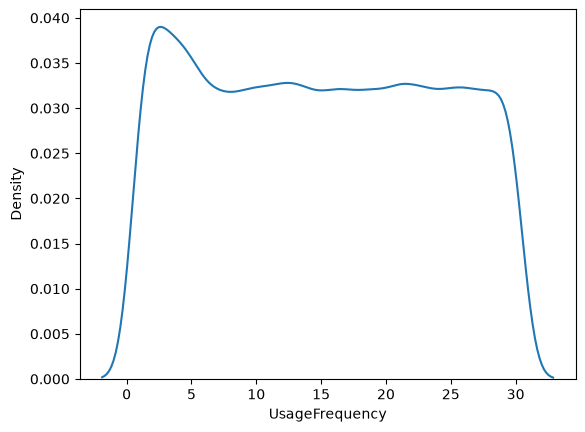

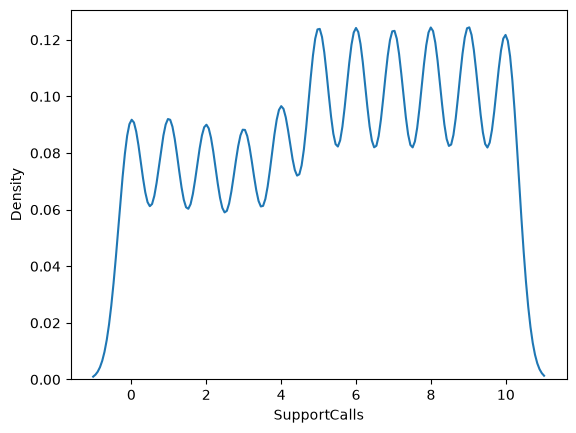

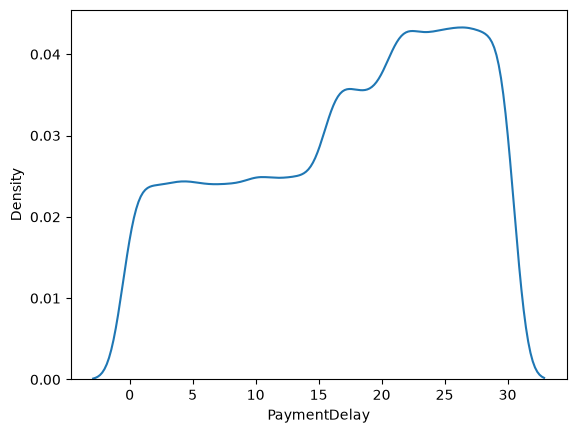

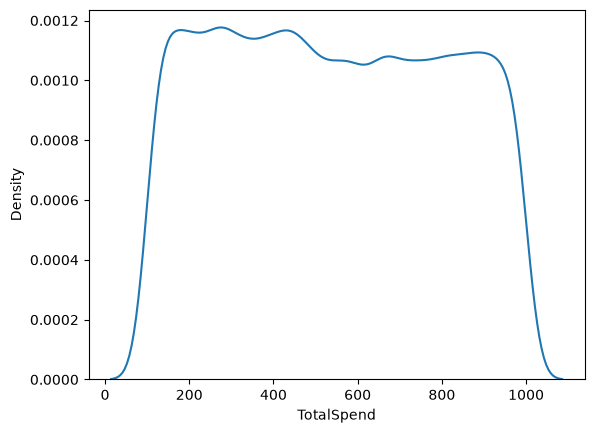

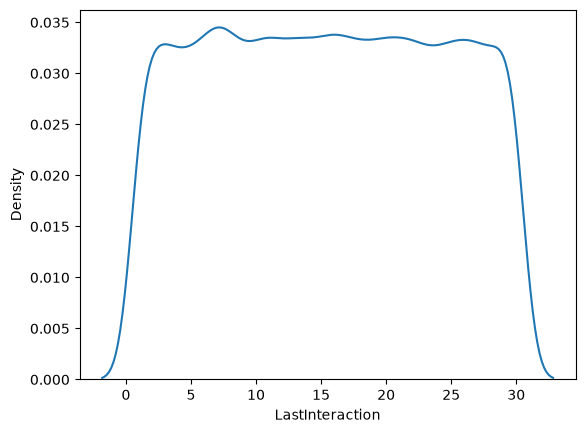

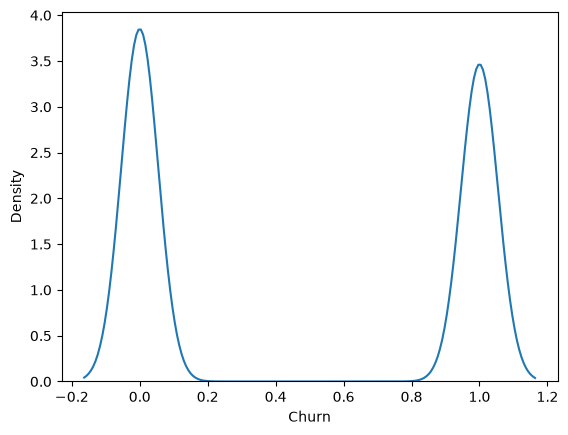

In [27]:

for col in numeric.columns:
    sns.kdeplot(x=col, data=numeric)
    plt.show()

In [28]:
str_type=ds.select_dtypes(include=['str'])
str_type

,Gender,SubscriptionType,ContractLength
0,Female,Basic,Monthly
1,Female,Standard,Monthly
2,Male,Premium,Annual
3,Male,Premium,Quarterly
4,Female,Standard,Annual
...,...,...,...
64369,Female,Basic,Quarterly
64370,Male,Standard,Annual
64371,Male,Premium,Monthly
64372,Female,Standard,Monthly


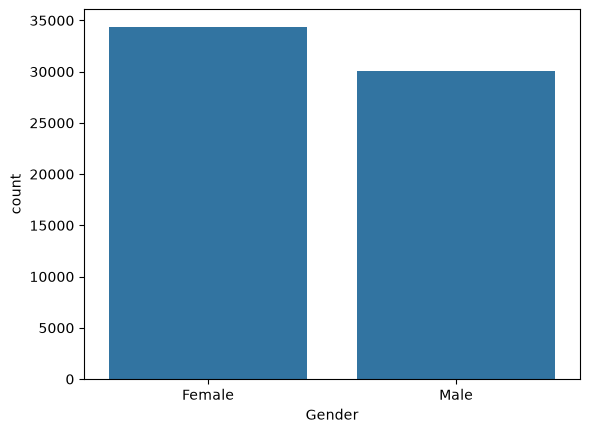

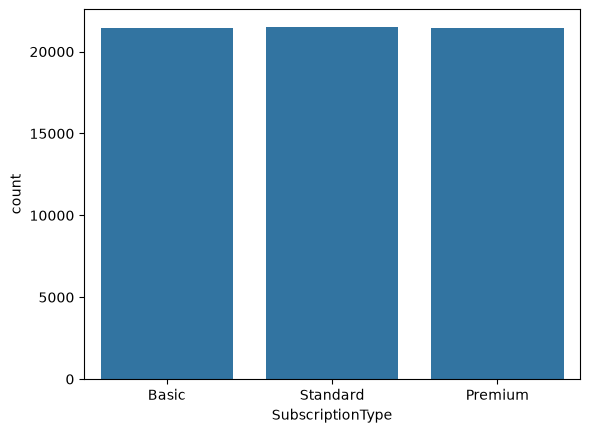

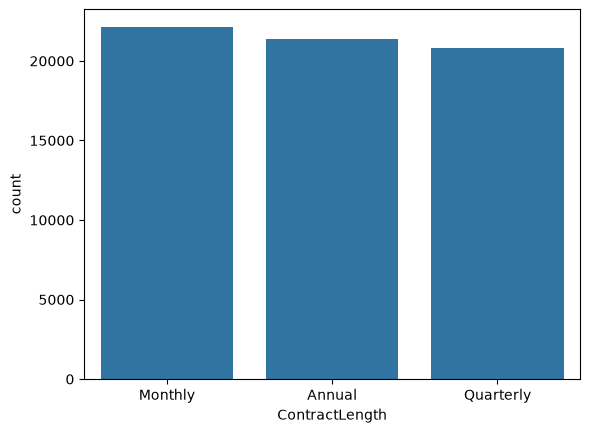

In [29]:
for col in str_type.columns:
    sns.countplot(x=col, data=str_type)
    plt.show()